# Exploratory Data Analysis (EDA)
The goal here is to check the distribution of our variables, find any anomalies, and discover patterns that influence final decision.

In [132]:
import kagglehub
path = kagglehub.dataset_download("annavictoria/speed-dating-experiment")
import pandas as pd
file_path = path + "/Speed Dating Data.csv"
df = pd.read_csv(file_path, encoding='latin-1')

## 1. Basic Descriptive Statistics
Before visualizations, let's look at the raw numbers. Here, we generate a statistical summary for attributes to get a basic understanding of their distributions.

In [133]:
key_columns = ['age', 'attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
stats_summary = df[key_columns].describe().T

stats_summary['median'] = df[key_columns].median()
stats_summary['skewness'] = df[key_columns].skew()

display(stats_summary)

,count,mean,std,min,25%,50%,75%,max,median,skewness
age,8283.0,26.358928,3.566763,18.0,24.0,26.0,28.0,55.0,26.0,1.069590
attr,8176.0,6.189995,1.950169,0.0,5.0,6.0,8.0,10.0,6.0,-0.320954
sinc,8101.0,7.175164,1.740315,0.0,6.0,7.0,8.0,10.0,7.0,-0.637899
intel,8082.0,7.368597,1.550453,0.0,6.0,7.0,8.0,10.0,7.0,-0.545198
fun,8028.0,6.400598,1.953702,0.0,5.0,7.0,8.0,10.0,7.0,-0.451428
amb,7666.0,6.777524,1.794055,0.0,6.0,7.0,8.0,10.0,7.0,-0.394012
shar,7311.0,5.474559,2.156363,0.0,4.0,6.0,7.0,10.0,6.0,-0.192328


## 2. Identifying Outliers 
We need to check if there are any extreme values that could mess up our analysis.

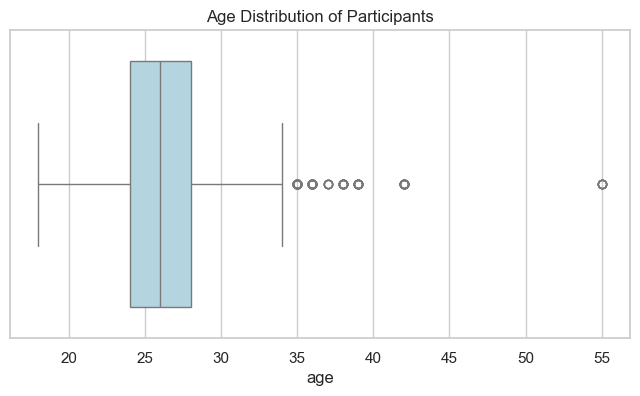

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['age'], color='lightblue')
plt.title('Age Distribution of Participants')
plt.show()

## 3. Demographics and Participant Profile
We need to analyze the basic demographics: age distribution and gender balance.

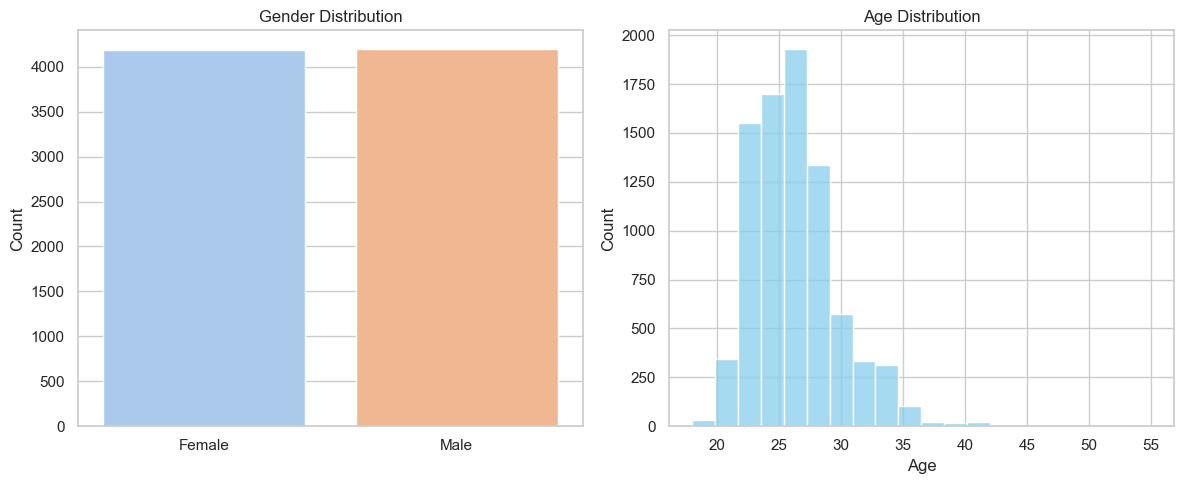

In [135]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

gender_data = df['gender'].map({0: 'Female', 1: 'Male'})
sns.countplot(x=gender_data, hue=gender_data, ax=ax1, palette='pastel')
ax1.set_title('Gender Distribution')
ax1.set_xlabel('')
ax1.set_ylabel('Count')

sns.histplot(data=df, x='age', bins=20, ax=ax2, color='skyblue')
ax2.set_title('Age Distribution')
ax2.set_xlabel('Age')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4. Distribution of Partner Ratings
During the speed dates, participants rated their partners on a scale from 1 to 10 across 6 key attribute. These histograms help us see if people were critics or if they used the full grading scale.

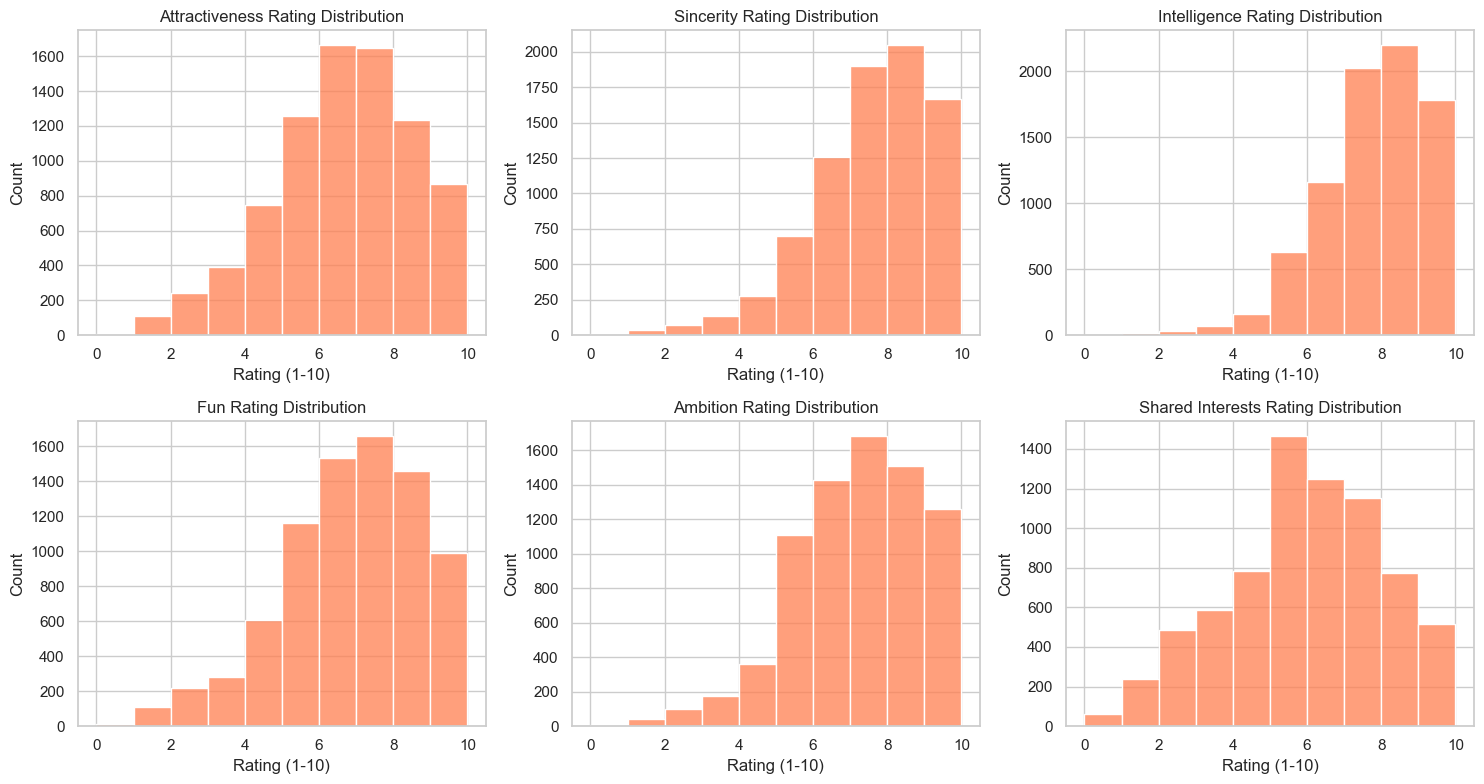

In [136]:
attributes = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
titles = ['Attractiveness', 'Sincerity', 'Intelligence', 'Fun', 'Ambition', 'Shared Interests']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(attributes):
    sns.histplot(data=df, x=col, bins=10, ax=axes[i], color='coral')
    axes[i].set_title(f'{titles[i]} Rating Distribution')
    axes[i].set_xlabel('Rating (1-10)')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 5. Participant Goals and Target Variable Imbalance
We check why people decided to join the event and we analyze the distribution of our target variable `match`.

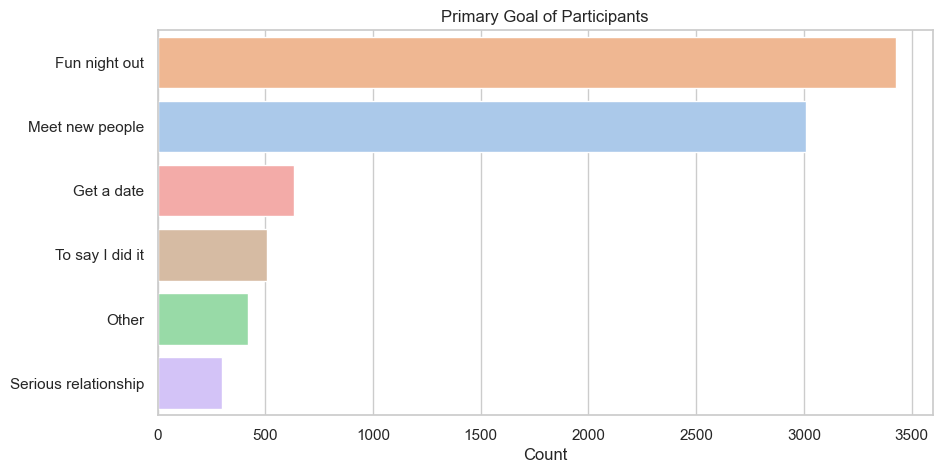

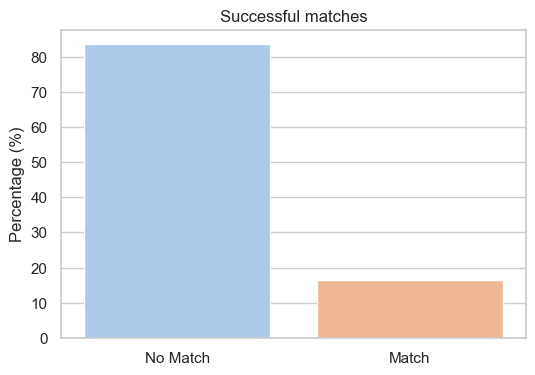

Percentage of successful matches: 16.47%


In [137]:
goal_map = {1: 'Fun night out', 2: 'Meet new people', 3: 'Get a date', 
            4: 'Serious relationship', 5: 'To say I did it', 6: 'Other'}
goal_labels = df['goal'].map(goal_map)
order_labels = goal_labels.value_counts().index

plt.figure(figsize=(10, 5))
sns.countplot(y=goal_labels, order=order_labels, hue=goal_labels, palette='pastel', legend=False)
plt.title('Primary Goal of Participants')
plt.xlabel('Count')
plt.ylabel('')
plt.show()

# Calculating match ratio to expose potential target class imbalance
match_counts = df['match'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
x_labels = match_counts.index.map({0: 'No Match', 1: 'Match'})
sns.barplot(x=x_labels, y=match_counts.values, hue=x_labels, palette='pastel', legend=False)
plt.title('Successful matches')
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.show()

print(f"Percentage of successful matches: {match_counts[1]:.2f}%")

## 6. The Impact of Hobbies on Popularity
The dataset includes 17 columns about participants' hobbies. After finding the most popular activities, we check their correlation with the amount of "Yes" votes a person received from their partners (`dec_o`). The goal is to see if having a specific interest statistically translates to being more attractive on a date.

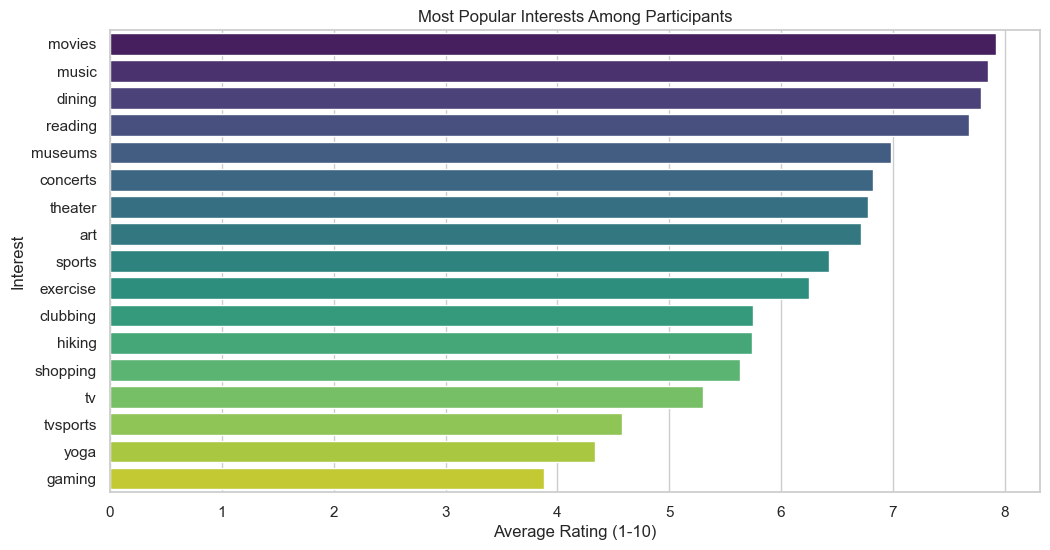

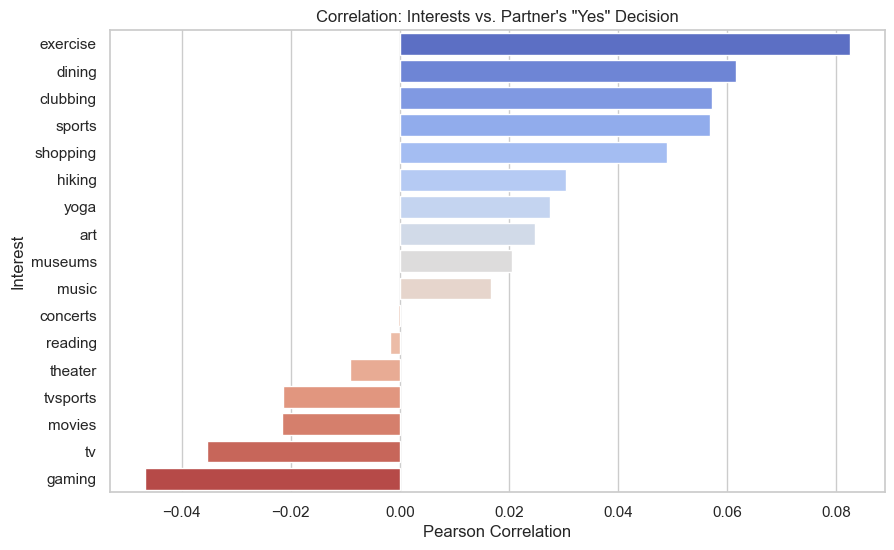

In [138]:
interests = ['sports', 'tvsports', 'exercise', 'dining', 'museums', 
             'art', 'hiking', 'gaming', 'clubbing', 'reading', 
             'tv', 'theater', 'movies', 'concerts', 'music', 
             'shopping', 'yoga']

# Calculate the average score for each hobby and sort them
popular_hobbies = df[interests].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=popular_hobbies.values, y=popular_hobbies.index, palette='viridis', hue=popular_hobbies.index, legend=False)
plt.title('Most Popular Interests Among Participants')
plt.xlabel('Average Rating (1-10)')
plt.ylabel('Interest')
plt.show()

# Does having a specific interest get you more "Yes" votes?
# We use 'dec_o' (decision of the partner) to measure participant popularity
interest_popularity_corr = df[interests + ['dec_o']].corr()['dec_o'].drop('dec_o').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=interest_popularity_corr.values, 
    y=interest_popularity_corr.index, 
    palette='coolwarm', 
    hue=interest_popularity_corr.index, 
    legend=False
)

plt.title('Correlation: Interests vs. Partner\'s "Yes" Decision')
plt.xlabel('Pearson Correlation')
plt.ylabel('Interest')
plt.show()

## 7. Gender Differences in Interests
In this section, we compare the hobby ratings of men and women. We want to see if there are any clear patterns in what each gender likes. This helps us understand the different profiles of participants in our dataset.

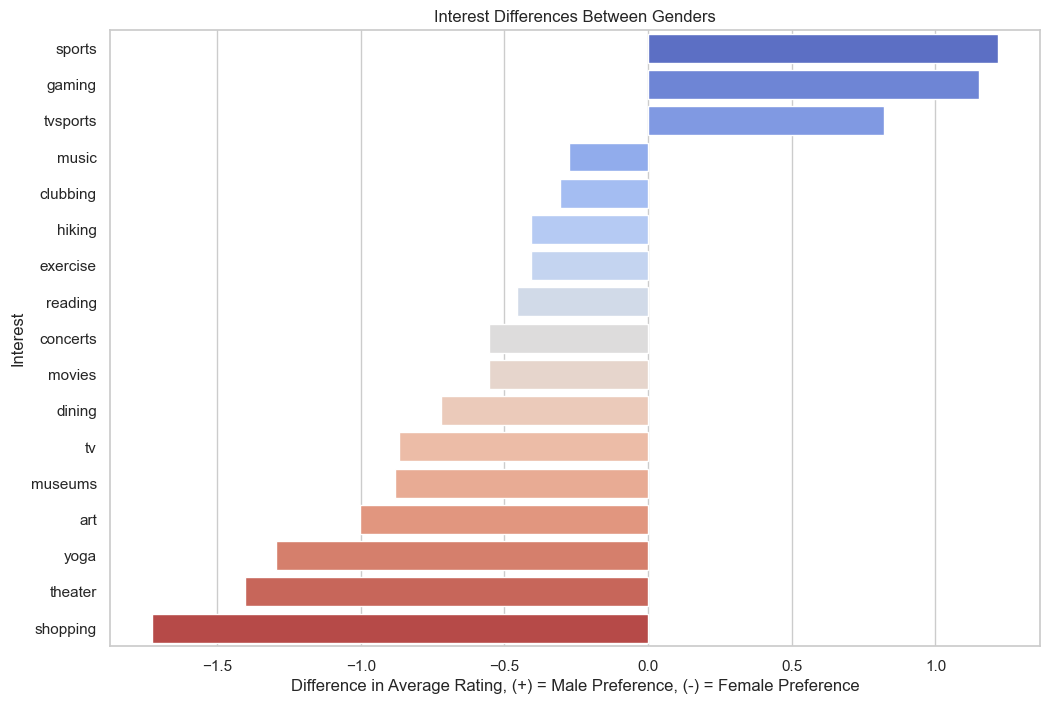

In [139]:
interests = ['sports', 'tvsports', 'exercise', 'dining', 'museums', 
             'art', 'hiking', 'gaming', 'clubbing', 'reading', 
             'tv', 'theater', 'movies', 'concerts', 'music', 
             'shopping', 'yoga']

# Calculate the average score for each hobby grouped by gender (0 = Female, 1 = Male)
gender_interests = df.groupby('gender')[interests].mean().T
gender_interests.columns = ['Female', 'Male']

# Positive values indicate a male preference, negative values indicate a female preference
gender_interests['Difference (Male - Female)'] = gender_interests['Male'] - gender_interests['Female']
gender_interests_sorted = gender_interests.sort_values(by='Difference (Male - Female)', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
x='Difference (Male - Female)',
    y=gender_interests_sorted.index, 
    data=gender_interests_sorted, 
    palette='coolwarm',
    hue=gender_interests_sorted.index,
    legend=False
)


plt.title('Interest Differences Between Genders')
plt.xlabel('Difference in Average Rating, (+) = Male Preference, (-) = Female Preference')
plt.ylabel('Interest')
plt.show()

## 8. Attributes vs Final Decision (Gender Differences)
We examine the differences in decision-making between men and women. By splitting the correlation matrix by gender, we can check if the traits that drive a successful date differ depending on whether the participant is male or female.

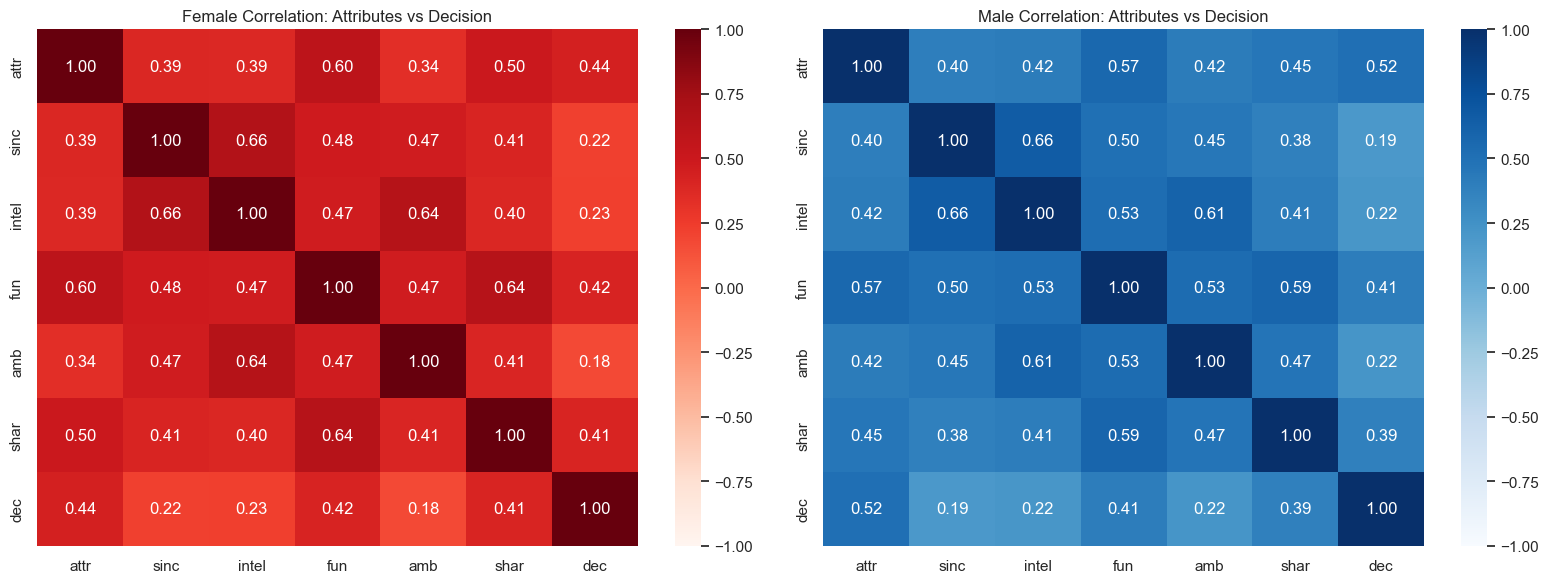

In [140]:
cols_to_corr = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'dec']

female_data = df[df['gender'] == 0][cols_to_corr]
male_data = df[df['gender'] == 1][cols_to_corr]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(female_data.corr(), annot=True, cmap='Reds', fmt=".2f", vmin=-1, vmax=1, ax=ax1)
ax1.set_title('Female Correlation: Attributes vs Decision')

sns.heatmap(male_data.corr(), annot=True, cmap='Blues', fmt=".2f", vmin=-1, vmax=1, ax=ax2)
ax2.set_title('Male Correlation: Attributes vs Decision')

plt.tight_layout()
plt.show()

## 9. Stated vs. Revealed Preferences
This step compares expectations against reality. We compare what participants claimed was important to them before the event with what they actually cared about during the dates. This analysis helps us spot key behavioral gaps in how people act versus what they say.

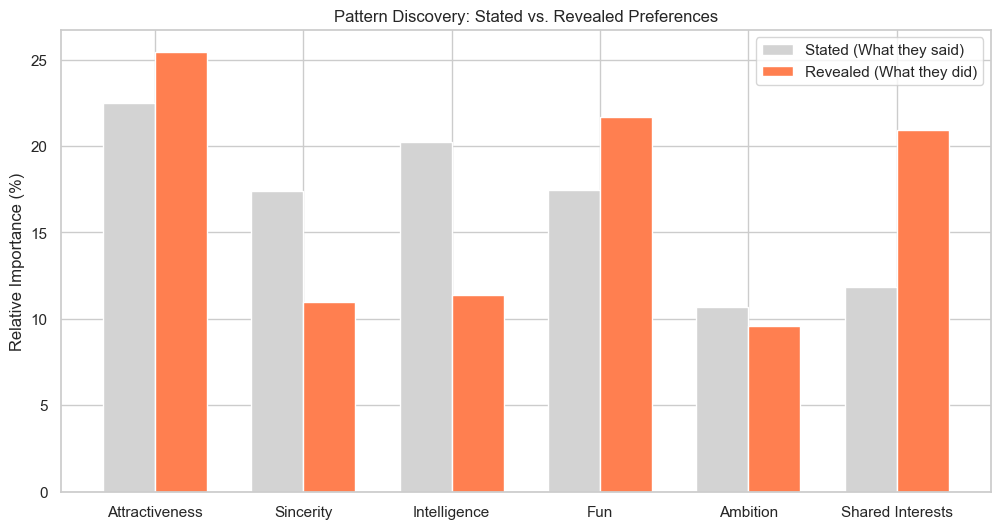

In [141]:
import numpy as np

stated_cols = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
stated_means = df[stated_cols].mean()

stated_normalized = (stated_means / stated_means.sum()) * 100

revealed_corr = df[['attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'dec']].corr()['dec'].drop('dec')

revealed_normalized = (revealed_corr / revealed_corr.sum()) * 100

labels = ['Attractiveness', 'Sincerity', 'Intelligence', 'Fun', 'Ambition', 'Shared Interests']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, stated_normalized.values, width, label='Stated (What they said)', color='lightgray')
ax.bar(x + width/2, revealed_normalized.values, width, label='Revealed (What they did)', color='coral')

ax.set_ylabel('Relative Importance (%)')
ax.set_title('Pattern Discovery: Stated vs. Revealed Preferences')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()